In [1]:
pip install pandas numpy matplotlib seaborn gradio jupyter


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_csv(r"D:\EDA 4th\dashboard_project\data\Traffic_Collision_Data_from_2010_to_Present (2).csv")

print(df.head())

   DR Number Date Reported Date Occurred  Time Occurred  Area ID  Area Name  \
0  212013850    09/03/2021    09/02/2021           2335       20    Olympic   
1  221417787    10/17/2022    10/17/2022           1620       14    Pacific   
2  221418141    10/26/2022    10/26/2022           1135       14    Pacific   
3  222017859    12/01/2022    12/01/2022            230       20    Olympic   
4  190319651    08/24/2019    08/24/2019            450        3  Southwest   

   Reporting District  Crime Code Crime Code Description  \
0                2021         997      TRAFFIC COLLISION   
1                1406         997      TRAFFIC COLLISION   
2                1434         997      TRAFFIC COLLISION   
3                2044         997      TRAFFIC COLLISION   
4                 356         997      TRAFFIC COLLISION   

                                       MO Codes  Victim Age Victim Sex  \
0       3004 3027 3034 4027 3036 3101 3401 3701        25.0          F   
1       4027 301

In [3]:
df.shape

(621677, 18)

In [4]:
df.columns

Index(['DR Number', 'Date Reported', 'Date Occurred', 'Time Occurred',
       'Area ID', 'Area Name', 'Reporting District', 'Crime Code',
       'Crime Code Description', 'MO Codes', 'Victim Age', 'Victim Sex',
       'Victim Descent', 'Premise Code', 'Premise Description', 'Address',
       'Cross Street', 'Location'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621677 entries, 0 to 621676
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   DR Number               621677 non-null  int64  
 1   Date Reported           621677 non-null  object 
 2   Date Occurred           621677 non-null  object 
 3   Time Occurred           621677 non-null  int64  
 4   Area ID                 621677 non-null  int64  
 5   Area Name               621677 non-null  object 
 6   Reporting District      621677 non-null  int64  
 7   Crime Code              621677 non-null  int64  
 8   Crime Code Description  621677 non-null  object 
 9   MO Codes                534353 non-null  object 
 10  Victim Age              533483 non-null  float64
 11  Victim Sex              610980 non-null  object 
 12  Victim Descent          610029 non-null  object 
 13  Premise Code            620718 non-null  float64
 14  Premise Description 

In [6]:
df.describe()

,DR Number,Time Occurred,Area ID,Reporting District,Crime Code,Victim Age,Premise Code
count,6.216770e+05,621677.000000,621677.000000,621677.000000,621677.0,533483.000000,620718.000000
mean,1.614646e+08,1352.403393,11.074330,1153.330234,997.0,41.399812,102.432688
std,3.754173e+07,605.519065,5.884491,589.575694,0.0,16.734094,23.542582
min,1.001000e+08,1.000000,1.000000,100.000000,997.0,10.000000,101.000000
25%,1.310074e+08,930.000000,6.000000,666.000000,997.0,28.000000,101.000000
50%,1.612200e+08,1430.000000,11.000000,1162.000000,997.0,39.000000,101.000000
75%,1.907062e+08,1825.000000,16.000000,1653.000000,997.0,51.000000,101.000000
max,2.521041e+08,2359.000000,21.000000,2199.000000,997.0,99.000000,970.000000


In [7]:
df.isnull().sum()

DR Number                     0
Date Reported                 0
Date Occurred                 0
Time Occurred                 0
Area ID                       0
Area Name                     0
Reporting District            0
Crime Code                    0
Crime Code Description        0
MO Codes                  87324
Victim Age                88194
Victim Sex                10697
Victim Descent            11648
Premise Code                959
Premise Description         960
Address                       0
Cross Street              29460
Location                      0
dtype: int64

In [8]:

df.drop_duplicates(inplace=True)

In [9]:
# Separate numeric and categorical columns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill numeric columns with mean
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Fill categorical columns with "Unknown"
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

print("Missing values handled successfully")

Missing values handled successfully


In [10]:
print(df.columns)

Index(['DR Number', 'Date Reported', 'Date Occurred', 'Time Occurred',
       'Area ID', 'Area Name', 'Reporting District', 'Crime Code',
       'Crime Code Description', 'MO Codes', 'Victim Age', 'Victim Sex',
       'Victim Descent', 'Premise Code', 'Premise Description', 'Address',
       'Cross Street', 'Location'],
      dtype='object')


In [11]:
df['Date Occurred'] = pd.to_datetime(df['Date Occurred'])

print(df['Date Occurred'].head())

0   2021-09-02
1   2022-10-17
2   2022-10-26
3   2022-12-01
4   2019-08-24
Name: Date Occurred, dtype: datetime64[ns]


In [12]:
df['Date Occurred'] = pd.to_datetime(
    df['Date Occurred'],
    errors='coerce'
)

print(df['Date Occurred'].head())

0   2021-09-02
1   2022-10-17
2   2022-10-26
3   2022-12-01
4   2019-08-24
Name: Date Occurred, dtype: datetime64[ns]


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12,6)

In [15]:
df = pd.read_csv(
    r"D:\EDA 4th\dashboard_project\data\Traffic_Collision_Data_from_2010_to_Present (2).csv"
)

In [16]:
df.head(5)

,DR Number,Date Reported,Date Occurred,Time Occurred,Area ID,Area Name,Reporting District,Crime Code,Crime Code Description,MO Codes,Victim Age,Victim Sex,Victim Descent,Premise Code,Premise Description,Address,Cross Street,Location
0,212013850,09/03/2021,09/02/2021,2335,20,Olympic,2021,997,TRAFFIC COLLISION,3004 3027 3034 4027 3036 3101 3401 3701,25.0,F,W,101.0,STREET,WILTON PL,6TH ST,"(34.063, -118.3141)"
1,221417787,10/17/2022,10/17/2022,1620,14,Pacific,1406,997,TRAFFIC COLLISION,4027 3011 3028 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,NATIONAL BL,MOTOR AV,"(34.029, -118.4113)"
2,221418141,10/26/2022,10/26/2022,1135,14,Pacific,1434,997,TRAFFIC COLLISION,4027 3011 3025 3034 3037 3101 3401 3701,21.0,NaN,NaN,101.0,STREET,PALMS BL,ROSEWOOD AV,"(34.0052, -118.4478)"
3,222017859,12/01/2022,12/01/2022,230,20,Olympic,2044,997,TRAFFIC COLLISION,3003 0913 3026 3035 3037 3101 3401 3701 4020,33.0,M,H,101.0,STREET,IROLO ST,SAN MARINO ST,"(34.0545, -118.3009)"
4,190319651,08/24/2019,08/24/2019,450,3,Southwest,356,997,TRAFFIC COLLISION,3036 3004 3026 3101 4003,22.0,M,H,101.0,STREET,JEFFERSON BL,NORMANDIE AV,"(34.0255, -118.3002)"


In [17]:
df.shape

(621677, 18)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621677 entries, 0 to 621676
Data columns (total 18 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   DR Number               621677 non-null  int64  
 1   Date Reported           621677 non-null  object 
 2   Date Occurred           621677 non-null  object 
 3   Time Occurred           621677 non-null  int64  
 4   Area ID                 621677 non-null  int64  
 5   Area Name               621677 non-null  object 
 6   Reporting District      621677 non-null  int64  
 7   Crime Code              621677 non-null  int64  
 8   Crime Code Description  621677 non-null  object 
 9   MO Codes                534353 non-null  object 
 10  Victim Age              533483 non-null  float64
 11  Victim Sex              610980 non-null  object 
 12  Victim Descent          610029 non-null  object 
 13  Premise Code            620718 non-null  float64
 14  Premise Description 

In [19]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed")

Duplicates Removed


In [20]:
df.isnull().sum()

DR Number                     0
Date Reported                 0
Date Occurred                 0
Time Occurred                 0
Area ID                       0
Area Name                     0
Reporting District            0
Crime Code                    0
Crime Code Description        0
MO Codes                  87324
Victim Age                88194
Victim Sex                10697
Victim Descent            11648
Premise Code                959
Premise Description         960
Address                       0
Cross Street              29460
Location                      0
dtype: int64

In [21]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

In [22]:
df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].mean()
)

In [23]:
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

In [24]:
df.columns

Index(['DR Number', 'Date Reported', 'Date Occurred', 'Time Occurred',
       'Area ID', 'Area Name', 'Reporting District', 'Crime Code',
       'Crime Code Description', 'MO Codes', 'Victim Age', 'Victim Sex',
       'Victim Descent', 'Premise Code', 'Premise Description', 'Address',
       'Cross Street', 'Location'],
      dtype='object')

In [25]:
df['Date Occurred'] = pd.to_datetime(
    df['Date Occurred'],
    errors='coerce'
)

In [26]:
df['Year'] = df['Date Occurred'].dt.year

df['Month'] = df['Date Occurred'].dt.month

In [27]:
df[['Date Occurred', 'Year', 'Month']].head()

,Date Occurred,Year,Month
0,2021-09-02,2021,9
1,2022-10-17,2022,10
2,2022-10-26,2022,10
3,2022-12-01,2022,12
4,2019-08-24,2019,8


In [28]:
df.describe()

,DR Number,Date Occurred,Time Occurred,Area ID,Reporting District,Crime Code,Victim Age,Premise Code,Year,Month
count,6.216770e+05,621677,621677.000000,621677.000000,621677.000000,621677.0,621677.000000,621677.000000,621677.000000,621677.000000
mean,1.614646e+08,2016-07-11 05:52:44.822246912,1352.403393,11.074330,1153.330234,997.0,41.399812,102.432688,2016.025756,6.537343
min,1.001000e+08,2010-01-01 00:00:00,1.000000,1.000000,100.000000,997.0,10.000000,101.000000,2010.000000,1.000000
25%,1.310074e+08,2013-06-11 00:00:00,930.000000,6.000000,666.000000,997.0,30.000000,101.000000,2013.000000,3.000000
50%,1.612200e+08,2016-07-21 00:00:00,1430.000000,11.000000,1162.000000,997.0,41.399812,101.000000,2016.000000,7.000000
75%,1.907062e+08,2019-04-05 00:00:00,1825.000000,16.000000,1653.000000,997.0,49.000000,101.000000,2019.000000,10.000000
max,2.521041e+08,2025-03-08 00:00:00,2359.000000,21.000000,2199.000000,997.0,99.000000,970.000000,2025.000000,12.000000
std,3.754173e+07,NaN,605.519065,5.884491,589.575694,0.0,15.501726,23.524416,3.751234,3.455276


In [29]:
print(" KPI SUMMARY ")

print("Total Records:", len(df))

print("Total Columns:", len(df.columns))

 KPI SUMMARY 
Total Records: 621677
Total Columns: 20


In [30]:
print(df.columns.tolist())

['DR Number', 'Date Reported', 'Date Occurred', 'Time Occurred', 'Area ID', 'Area Name', 'Reporting District', 'Crime Code', 'Crime Code Description', 'MO Codes', 'Victim Age', 'Victim Sex', 'Victim Descent', 'Premise Code', 'Premise Description', 'Address', 'Cross Street', 'Location', 'Year', 'Month']


In [31]:
df['Area Name'].mode()[0]

'77th Street'

In [32]:
for col in df.columns:
    print(col)
    

DR Number
Date Reported
Date Occurred
Time Occurred
Area ID
Area Name
Reporting District
Crime Code
Crime Code Description
MO Codes
Victim Age
Victim Sex
Victim Descent
Premise Code
Premise Description
Address
Cross Street
Location
Year
Month


In [33]:
df['Crime Code Description'].mode()[0]

'TRAFFIC COLLISION'

In [34]:
df.columns

Index(['DR Number', 'Date Reported', 'Date Occurred', 'Time Occurred',
       'Area ID', 'Area Name', 'Reporting District', 'Crime Code',
       'Crime Code Description', 'MO Codes', 'Victim Age', 'Victim Sex',
       'Victim Descent', 'Premise Code', 'Premise Description', 'Address',
       'Cross Street', 'Location', 'Year', 'Month'],
      dtype='object')

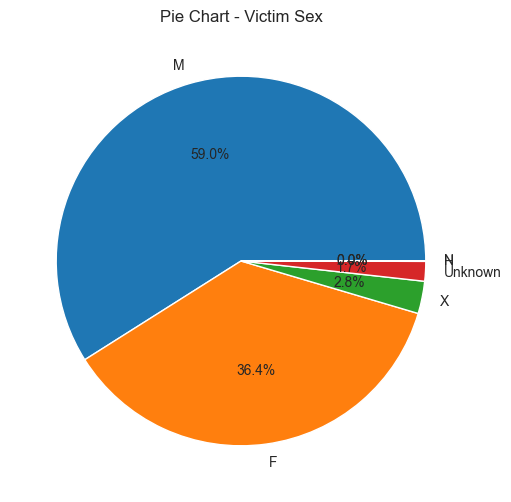

In [35]:
col = "Victim Sex"   # change this if needed

df[col].value_counts().head(6).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Pie Chart - " + col)
plt.ylabel("")
plt.show()

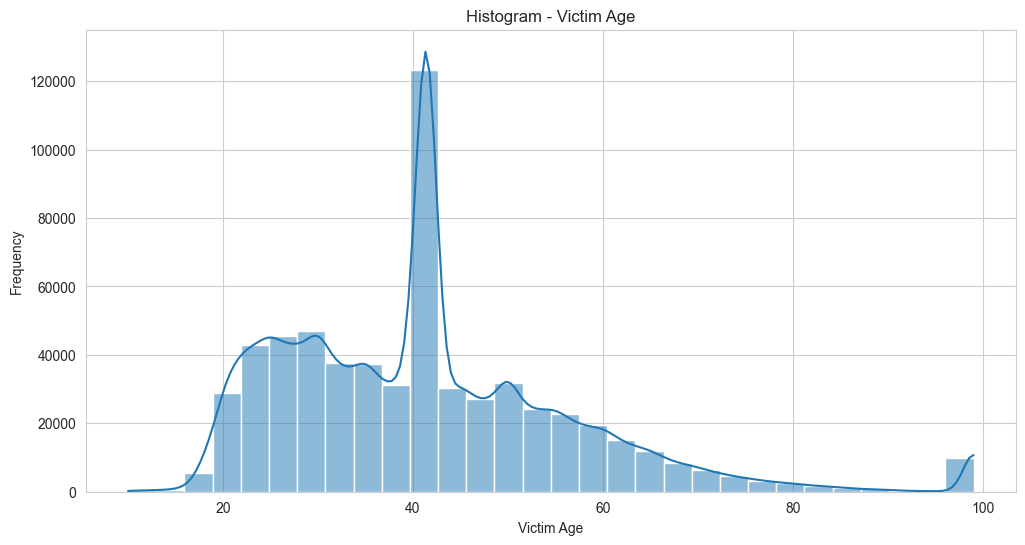

In [36]:
num_col = "Victim Age"   # change if needed

sns.histplot(df[num_col], bins=30, kde=True)

plt.title("Histogram - " + num_col)
plt.xlabel(num_col)
plt.ylabel("Frequency")

plt.show()

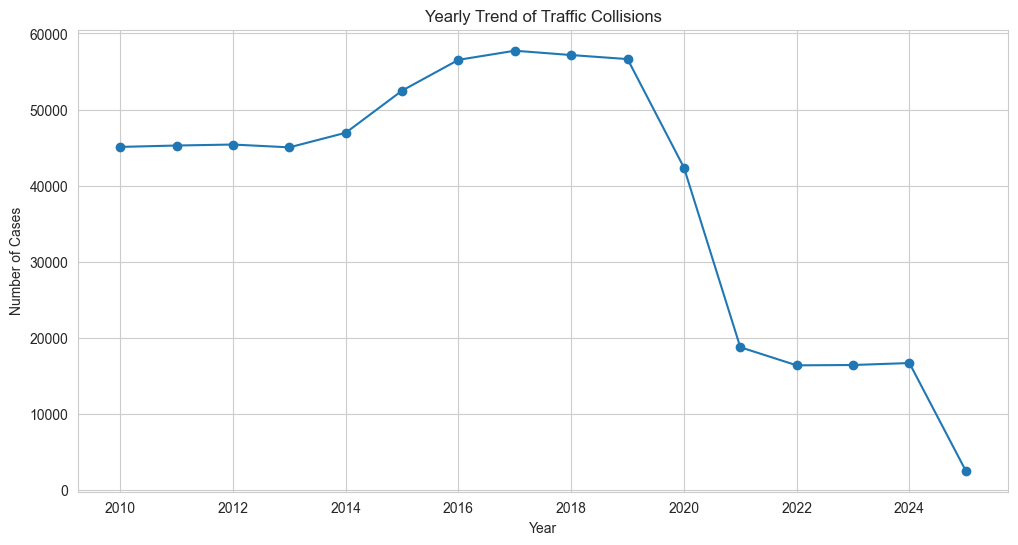

In [37]:
yearly = df.groupby('Year').size()

plt.plot(yearly.index, yearly.values, marker='o')

plt.title("Yearly Trend of Traffic Collisions")
plt.xlabel("Year")
plt.ylabel("Number of Cases")

plt.grid(True)
plt.show()

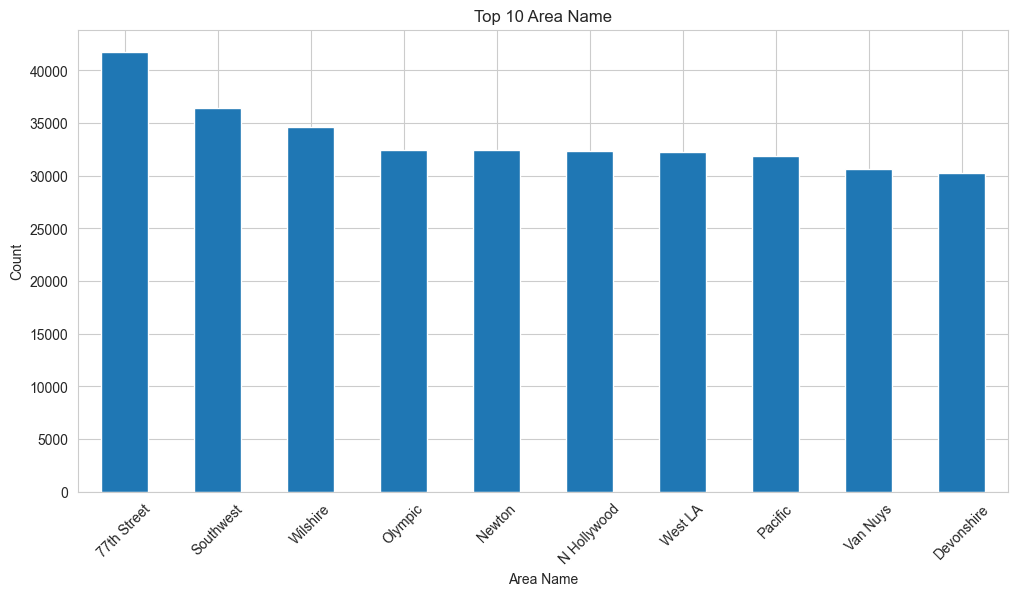

In [38]:
cat_col = "Area Name"  # change this based on your dataset

df[cat_col].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 " + cat_col)
plt.xlabel(cat_col)
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

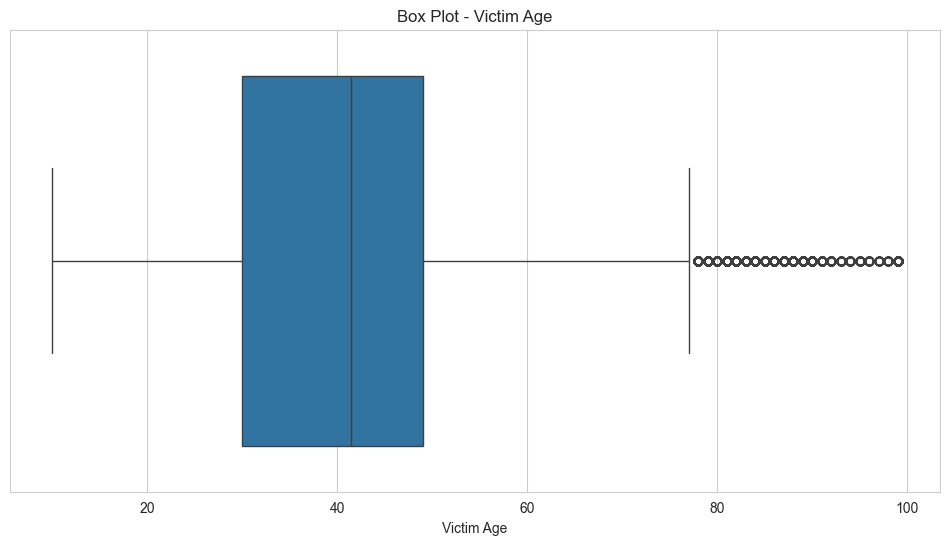

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

df.columns = df.columns.str.strip()
df["Victim Age"] = pd.to_numeric(df["Victim Age"], errors="coerce")
df = df.dropna(subset=["Victim Age"])

sns.boxplot(x=df["Victim Age"])

plt.title("Box Plot - Victim Age")
plt.show()

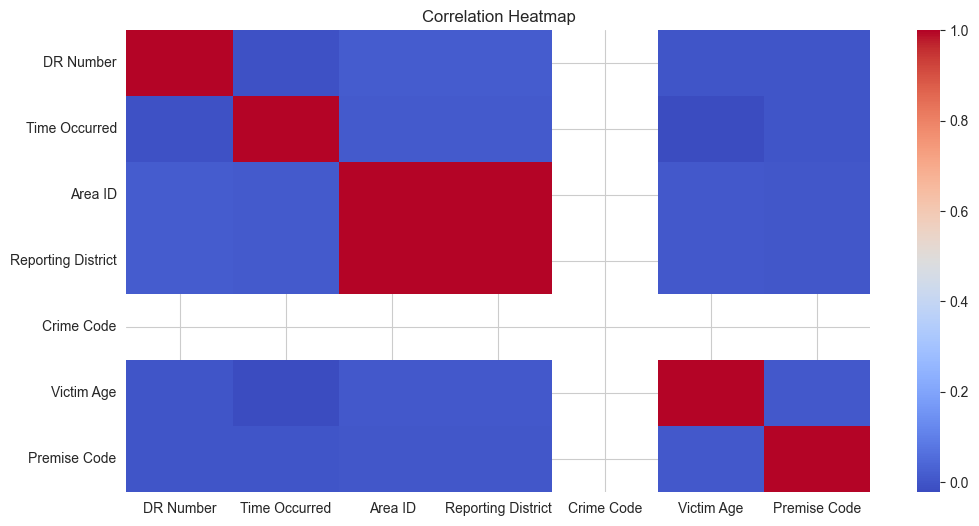

In [40]:
numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

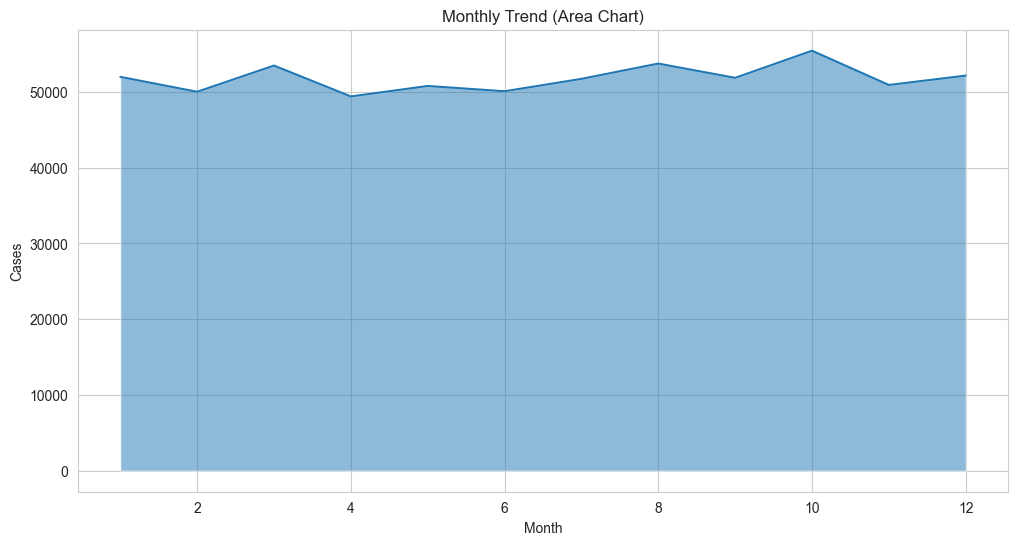

In [41]:
monthly = df.groupby('Month').size()

plt.fill_between(monthly.index, monthly.values, alpha=0.5)
plt.plot(monthly.index, monthly.values)

plt.title("Monthly Trend (Area Chart)")
plt.xlabel("Month")
plt.ylabel("Cases")

plt.show()

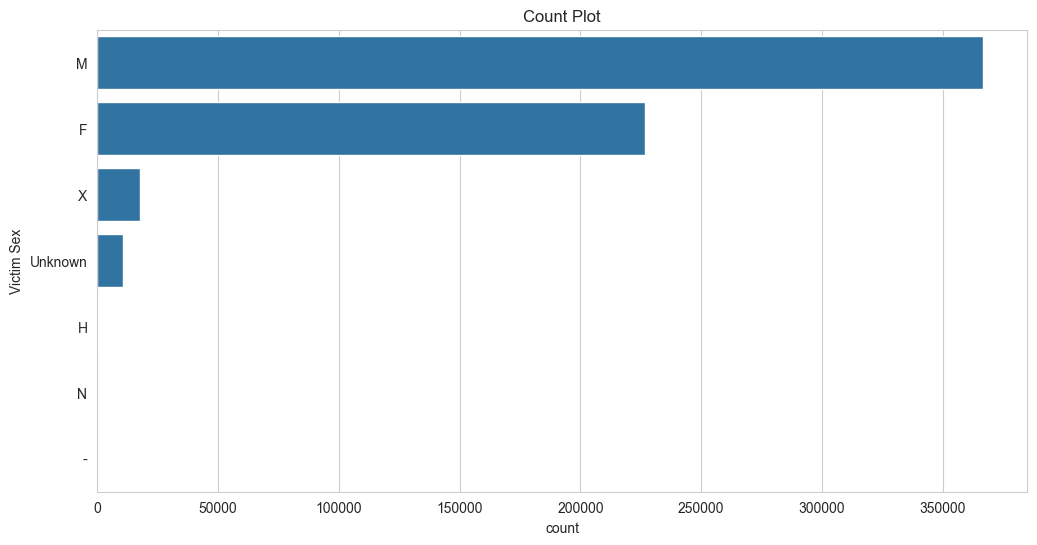

In [42]:
sns.countplot(
    y="Victim Sex",
    data=df,
    order=df["Victim Sex"].value_counts().index
)

plt.title("Count Plot")
plt.show()

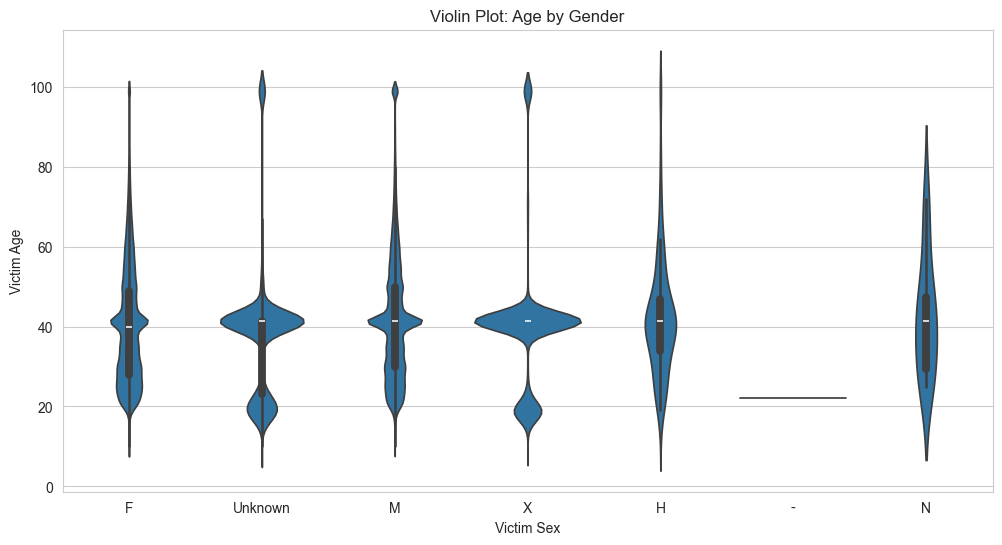

In [43]:
sns.violinplot(
    x="Victim Sex",
    y="Victim Age",
    data=df
)

plt.title("Violin Plot: Age by Gender")
plt.show()